In [ ]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
file_path ='/content/drive/MyDrive/data/SpamAssassin_balanced.csv','/content/drive/MyDrive/data/llm_legit.csv','/content/drive/MyDrive/data/llm_phishing.csv'

In [ ]:
import pandas as pd
import csv
import sys
csv.field_size_limit(sys.maxsize)


human_dataset= pd.read_csv(
    '/content/drive/MyDrive/data/SpamAssassin_balanced.csv',
    engine="python"
)

llm_legit = pd.read_csv(
    '/content/drive/MyDrive/data/llm_legit.csv',
    engine="python"
)


In [ ]:
def load_llm_phishing_correctly(path):
    texts = []
    labels = []

    with open(path, "r", encoding="utf-8") as f:
        next(f)  # skip header

        for line in f:
            line = line.strip()

            if line:
                # Split only at the LAST comma
                text, label = line.rsplit(",", 1)

                texts.append(text)
                labels.append(int(label))

    df = pd.DataFrame({
        "text": texts,
        "label": labels
    })

    return df


llm_phishing = load_llm_phishing_correctly(
    '/content/drive/MyDrive/data/llm_phishing.csv'
)


In [ ]:
print(human_dataset.shape)

(2000, 2)


In [ ]:
print("Human Dataset Columns:")
print(human_dataset.columns)
print()

Human Dataset Columns:
Index(['text', 'label'], dtype='object')



In [ ]:
print("LLM Legit Columns:")
print(llm_legit.columns)
print()

print("LLM Phishing Columns:")
print(llm_phishing.columns)
print()


LLM Legit Columns:
Index(['text', 'label'], dtype='object')

LLM Phishing Columns:
Index(['text', 'label'], dtype='object')



In [ ]:
# LLM Legitimate → 2
llm_legit['label'] = 2

# LLM Phishing → 3
llm_phishing['label'] = 3


In [ ]:
print("Human Generated email Sample:")
print(human_dataset[['text', 'label']].head())
print()




Human Generated email Sample:
                                                text  label
0  Re: New Sequences Window Date:        Wed, 21 ...      0
1  [zzzzteana] RE: Alexander Martin A posted:\nTa...      0
2  [zzzzteana] Moscow bomber Man Threatens Explos...      0
3  [IRR] Klez: The Virus That  Won't Die Klez: Th...      0
4  Re: [zzzzteana] Nothing like mama used to make...      0



In [ ]:
print("Human Legit Label Counts:")
print(human_dataset[human_dataset['label'] == 0]['label'].value_counts())
print()

print("Human Phishing Label Counts:")
print(human_dataset[human_dataset['label'] == 1]['label'].value_counts())
print()

print("Overall Label Counts:")
print(human_dataset['label'].value_counts())

Human Legit Label Counts:
label
0    1000
Name: count, dtype: int64

Human Phishing Label Counts:
label
1    1000
Name: count, dtype: int64

Overall Label Counts:
label
0    1000
1    1000
Name: count, dtype: int64


In [ ]:
print("LLM Legit Sample:")
print(llm_legit[['text', 'label']].head())
print()

print("LLM Phishing Sample:")
print(llm_phishing[['text', 'label']].head())


LLM Legit Sample:
                                                text  label
0  Dear Michael, I hope this message finds you we...      2
1  Dear Jennifer, We hope you're doing well. We'r...      2
2  Dear Robert, Your attention is urgently requir...      2
3  Dear Emily, We're writing to remind you of the...      2
4  Dear William, We need your immediate attention...      2

LLM Phishing Sample:
                                                text  label
0  Dear User, We have received reports indicating...      3
1  Dear Sarah Thompson, I hope this email finds y...      3
2  Dear Michael, I hope this email finds you well...      3
3  Dear Sarah, I am Daniel Anderson, the Security...      3
4  Dear John, I hope this email finds you well. A...      3


In [ ]:
print("LLM Legit Label Counts:")
print(llm_legit['label'].value_counts())
print()

print("LLM Phishing Label Counts:")
print(llm_phishing['label'].value_counts())


LLM Legit Label Counts:
label
2    1000
Name: count, dtype: int64

LLM Phishing Label Counts:
label
3    1000
Name: count, dtype: int64


In [ ]:
human_dataset = human_dataset[['text', 'label']]


llm_legit = llm_legit[['text', 'label']]
llm_phishing = llm_phishing[['text', 'label']]


In [ ]:
df = pd.concat([
    human_dataset,
    llm_legit,
    llm_phishing
], ignore_index=True)

print("Final Dataset Shape:", df.shape)
print(df['label'].value_counts())


Final Dataset Shape: (4000, 2)
label
0    1000
1    1000
2    1000
3    1000
Name: count, dtype: int64


In [ ]:
print("Merged Dataset Columns:")
print(df.columns.tolist())
print(df.head())


Merged Dataset Columns:
['text', 'label']
                                                text  label
0  Re: New Sequences Window Date:        Wed, 21 ...      0
1  [zzzzteana] RE: Alexander Martin A posted:\nTa...      0
2  [zzzzteana] Moscow bomber Man Threatens Explos...      0
3  [IRR] Klez: The Virus That  Won't Die Klez: Th...      0
4  Re: [zzzzteana] Nothing like mama used to make...      0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = df[['text', 'label']]

df.to_csv(
    '/content/drive/MyDrive/data/merged_dataset.csv',
    index=False
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    4000 non-null   object
 1   label   4000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 62.6+ KB
None


In [ ]:
print("Merged Dataset Columns:")
print(df.columns.tolist())
print(df.head())

Merged Dataset Columns:
['text', 'label']
                                                text  label
0  Re: New Sequences Window Date:        Wed, 21 ...      0
1  [zzzzteana] RE: Alexander Martin A posted:\nTa...      0
2  [zzzzteana] Moscow bomber Man Threatens Explos...      0
3  [IRR] Klez: The Virus That  Won't Die Klez: Th...      0
4  Re: [zzzzteana] Nothing like mama used to make...      0


In [ ]:
import pandas as pd
df = pd.read_csv(
   '/content/drive/MyDrive/data/merged_dataset.csv'
)


In [ ]:
# Remove rows where text is missing
df = df.dropna(subset=['text'])

# Convert to string safely
df['text'] = df['text'].astype(str)


In [ ]:
df['text'] = df['text'].str.strip()


In [ ]:
# Remove nulls
df.dropna(inplace=True)

df['label'] = df['label'].astype(int)

# Lowercasing only
def clean_text(text):
    return text.lower()

df['text'] = df['text'].apply(clean_text)

In [ ]:
print("Total duplicates:", df.duplicated(subset=['text']).sum())

Total duplicates: 2


In [ ]:
# ===============================
#  Remove Duplicate Emails
# ===============================

print("Original dataset shape:", df.shape)

df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("After removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated(subset=["text"]).sum())
print(df['label'].value_counts().sort_index())


Original dataset shape: (4000, 2)
After removing duplicates: (3998, 2)
Remaining duplicates: 0
label
0    1000
1    1000
2     998
3    1000
Name: count, dtype: int64


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3998 entries, 0 to 3997
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    3998 non-null   object
 1   label   3998 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 62.6+ KB
None


In [ ]:
df.shape

(3998, 2)

In [ ]:
df.tail()

,text,label
3993,"hi olivia, i hope this email finds you in good...",3
3994,"dear michael, i hope this email finds you well...",3
3995,"hi jessica, i hope this email finds you in goo...",3
3996,"dear benjamin, i hope this email finds you wel...",3
3997,"hi samantha, i hope this email finds you in go...",3


In [ ]:

from collections import Counter
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns

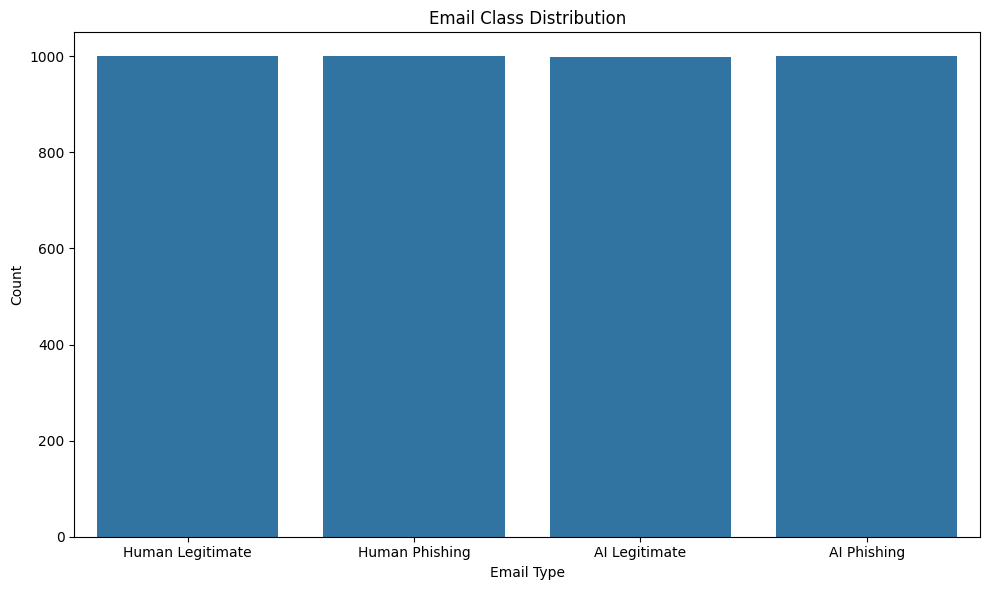

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='label', order=[0, 1, 2, 3])

plt.title('Email Class Distribution')

plt.xticks(
    [0, 1, 2, 3],
    ['Human Legitimate', 'Human Phishing', 'AI Legitimate', 'AI Phishing']
)

plt.ylabel('Count')
plt.xlabel('Email Type')
plt.tight_layout()
plt.show()

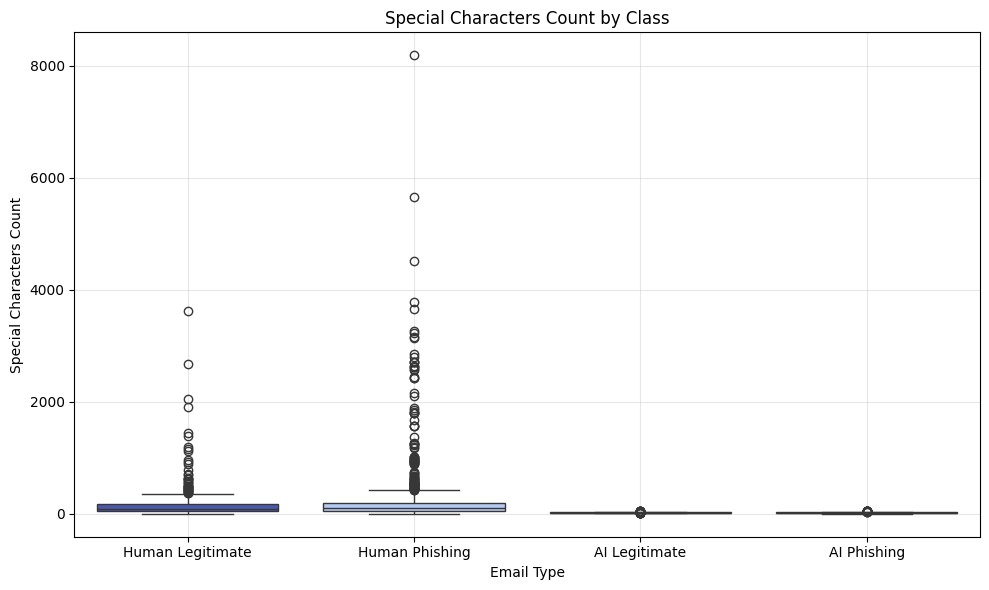

In [ ]:
df['special_chars'] = df['text'].apply(
    lambda x: sum(not c.isalnum() and not c.isspace() for c in x)
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='label',        # change to 'final_label' if that's your column name
    y='special_chars',
    data=df,
    palette='coolwarm',
    hue = 'label',
    legend =False

)

plt.xticks(
    [0, 1, 2, 3],
    ['Human Legitimate', 'Human Phishing', 'AI Legitimate', 'AI Phishing']
)

plt.title('Special Characters Count by Class')
plt.xlabel('Email Type')
plt.ylabel('Special Characters Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

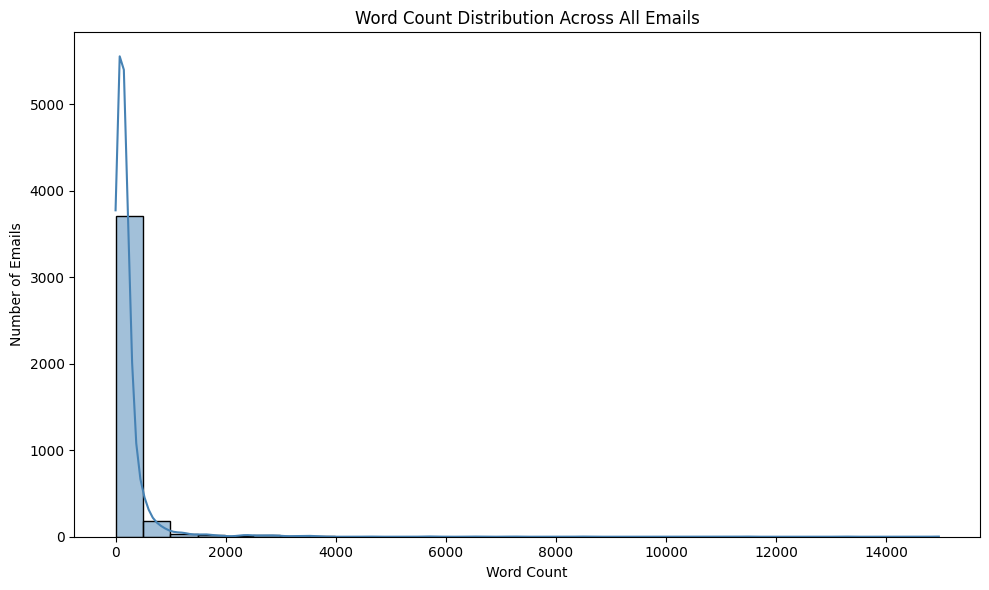

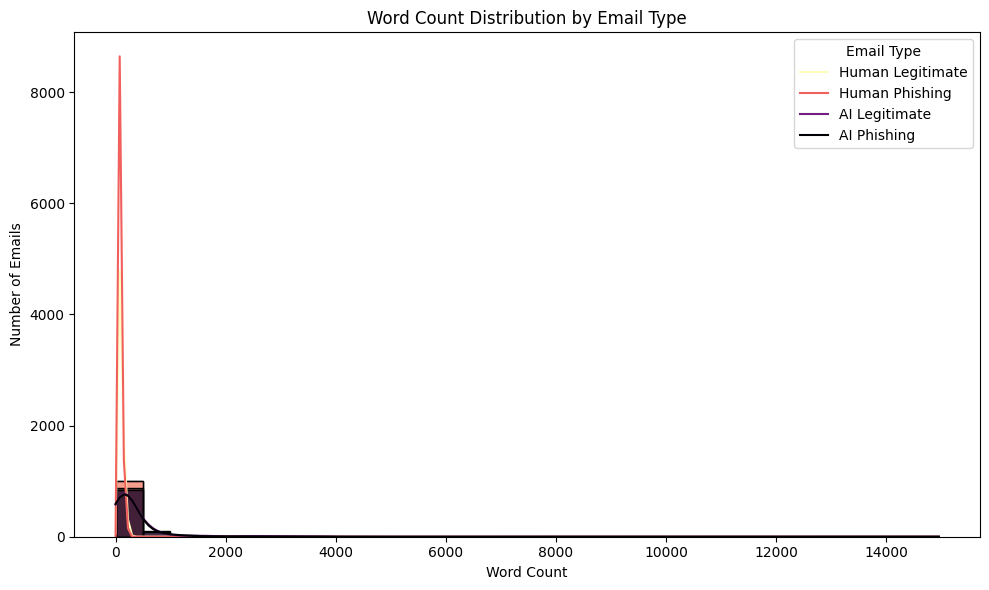

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create word count column
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Plot 1: Overall word count distribution
plt.figure(figsize=(10, 6))
sns.histplot(
    df['word_count'],
    bins=30,
    kde=True,
    color='steelblue'
)
plt.title('Word Count Distribution Across All Emails')
plt.xlabel('Word Count')
plt.ylabel('Number of Emails')
plt.tight_layout()
plt.show()

# Plot 2: Word count by class
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='word_count',
    hue='label',          # change to 'final_label' if that's your column name
    bins=30,
    kde=True,
    palette='magma',
    alpha=0.6
)

plt.title('Word Count Distribution by Email Type')
plt.xlabel('Word Count')
plt.ylabel('Number of Emails')

# Fix legend labels
plt.legend(
    labels=['Human Legitimate', 'Human Phishing', 'AI Legitimate', 'AI Phishing'],
    title='Email Type'
)

plt.tight_layout()
plt.show()

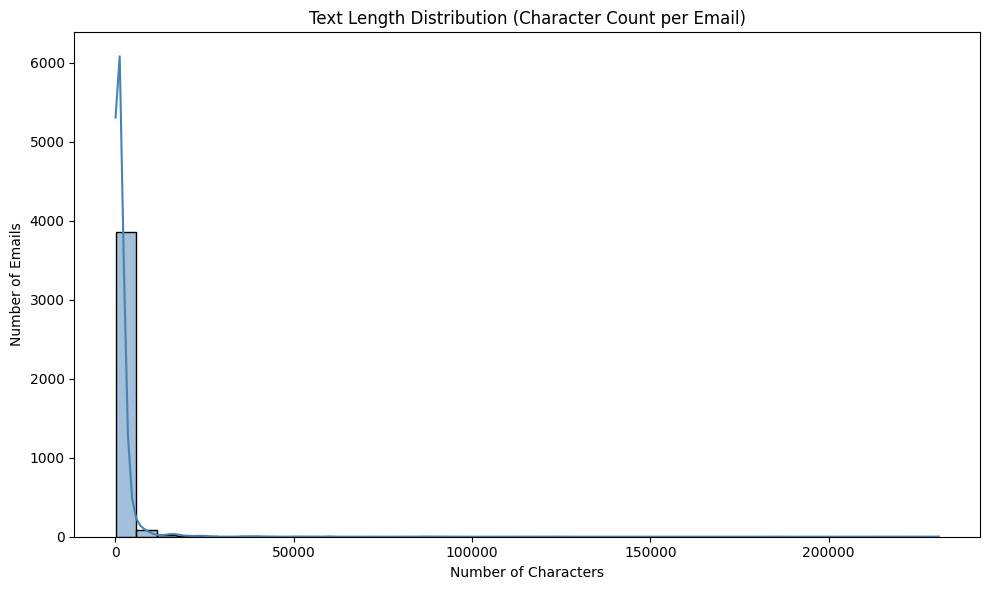

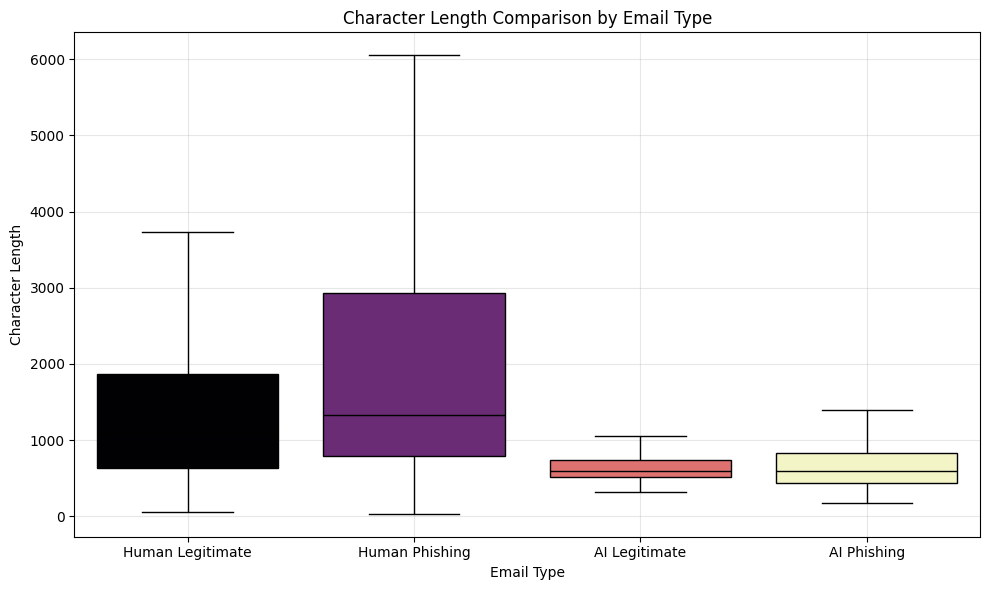

        count         mean           std    min     25%     50%      75%  \
label                                                                      
0      1000.0  2027.151000   4951.246314   58.0  630.50  1101.5  1872.50   
1      1000.0  3499.397000  11531.516872   35.0  788.75  1337.0  2932.50   
2       998.0   642.651303    178.995432  327.0  518.00   594.0   734.75   
3      1000.0   657.423000    308.788401  173.0  439.75   600.0   828.25   

            max  
label            
0       88012.0  
1      230917.0  
2        1517.0  
3        2111.0  


In [ ]:
df['char_length'] = df['text'].apply(lambda x: len(str(x)))

# Plot 1: Overall character length distribution
plt.figure(figsize=(10, 6))
sns.histplot(
    df['char_length'],
    bins=40,
    kde=True,
    color='steelblue'
)
plt.title('Text Length Distribution (Character Count per Email)')
plt.xlabel('Number of Characters')
plt.ylabel('Number of Emails')
plt.tight_layout()
plt.show()

# Plot 2: Character length by class
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='label',            # change to 'final_label' if that's your column name
    y='char_length',
    palette='magma',
    hue= 'label',
    legend= False,
    showfliers=False      # hides extreme outliers for cleaner plot
)
plt.xticks(
    [0, 1, 2, 3],
    ['Human Legitimate', 'Human Phishing', 'AI Legitimate', 'AI Phishing']
)
plt.title('Character Length Comparison by Email Type')
plt.xlabel('Email Type')
plt.ylabel('Character Length')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(df.groupby('label')['char_length'].describe())

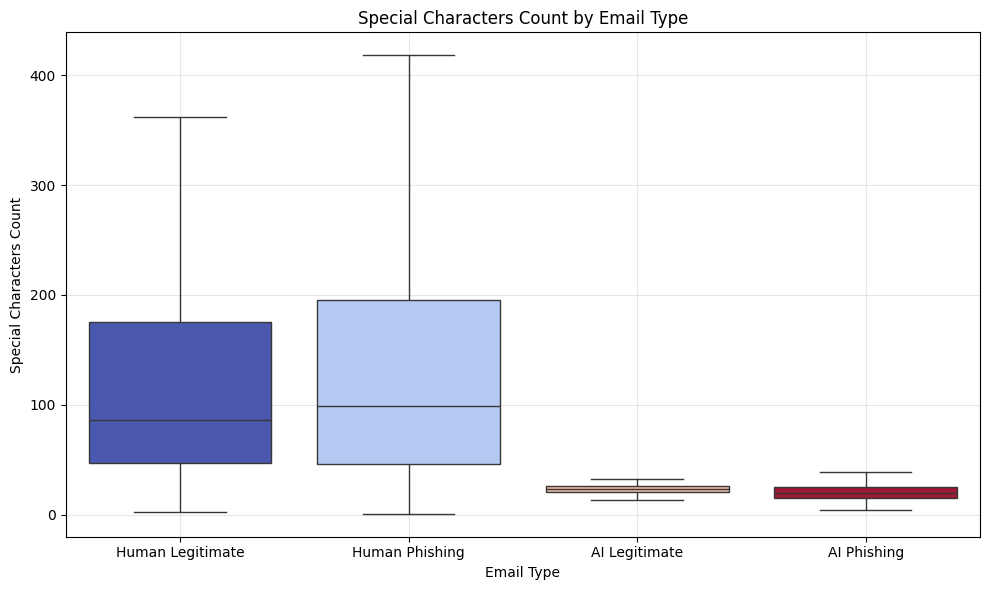

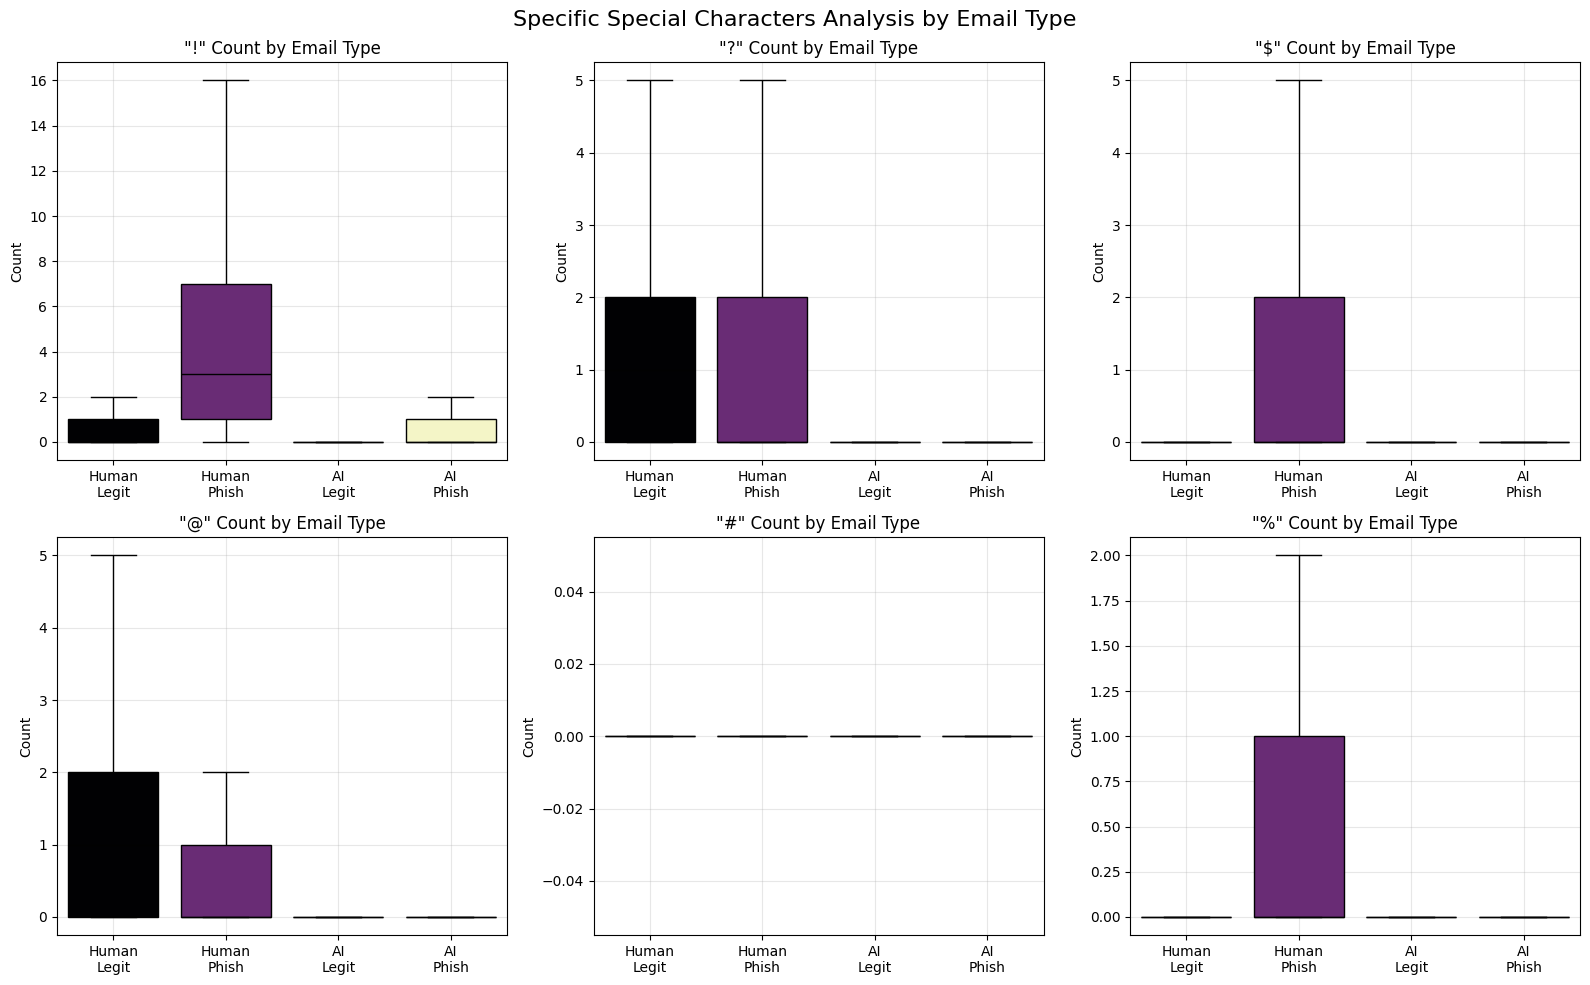

Special Characters Stats by Class:
        count        mean         std  min    25%   50%    75%     max
label                                                                 
0      1000.0  137.075000  212.326489  3.0  46.75  86.0  175.0  3626.0
1      1000.0  245.709000  563.038322  1.0  46.00  99.0  195.0  8184.0
2       998.0   23.856713    4.605011  9.0  21.00  24.0   26.0    46.0
3      1000.0   20.846000    7.753606  4.0  15.00  20.0   25.0    52.0


In [ ]:
# ============================================================
#  SPECIAL CHARACTERS ANALYSIS
# ============================================================

# Count special characters per email
df['special_chars'] = df['text'].apply(
    lambda x: sum(not c.isalnum() and not c.isspace() for c in str(x))
)

# Count specific special characters
df['exclamation'] = df['text'].apply(lambda x: str(x).count('!'))
df['question']    = df['text'].apply(lambda x: str(x).count('?'))
df['dollar']      = df['text'].apply(lambda x: str(x).count('$'))
df['at_sign']     = df['text'].apply(lambda x: str(x).count('@'))
df['hash']        = df['text'].apply(lambda x: str(x).count('#'))
df['percent']     = df['text'].apply(lambda x: str(x).count('%'))

label_names = {0: 'Human Legitimate', 1: 'Human Phishing', 2: 'AI Legitimate', 3: 'AI Phishing'}

# Plot 1: Overall special chars boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, x='label', y='special_chars',
    palette='coolwarm', hue='label', legend=False,
    showfliers=False
)
plt.xticks([0,1,2,3], list(label_names.values()))
plt.title('Special Characters Count by Email Type')
plt.xlabel('Email Type')
plt.ylabel('Special Characters Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Specific special characters per class
special_char_cols = ['exclamation', 'question', 'dollar', 'at_sign', 'hash', 'percent']
special_char_labels = ['!', '?', '$', '@', '#', '%']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, char) in enumerate(zip(special_char_cols, special_char_labels)):
    sns.boxplot(
        data=df, x='label', y=col,
        palette='magma', hue='label',
        legend=False, showfliers=False,
        ax=axes[i]
    )
    axes[i].set_xticks([0,1,2,3])
    axes[i].set_xticklabels(['Human\nLegit', 'Human\nPhish', 'AI\nLegit', 'AI\nPhish'])
    axes[i].set_title(f'"{char}" Count by Email Type')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Specific Special Characters Analysis by Email Type', fontsize=16)
plt.tight_layout()
plt.show()

# Print stats
print("Special Characters Stats by Class:")
print(df.groupby('label')['special_chars'].describe())

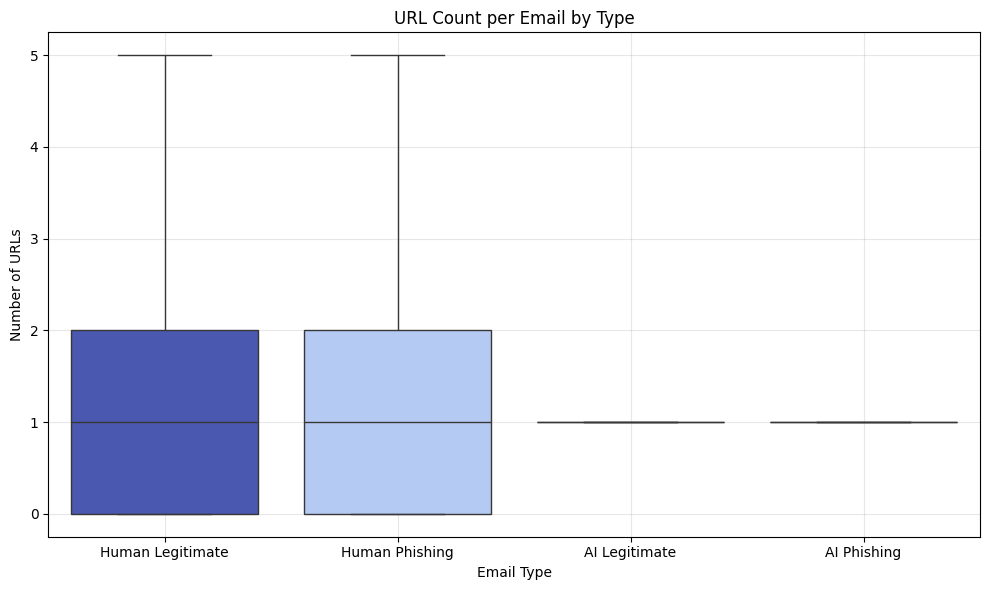

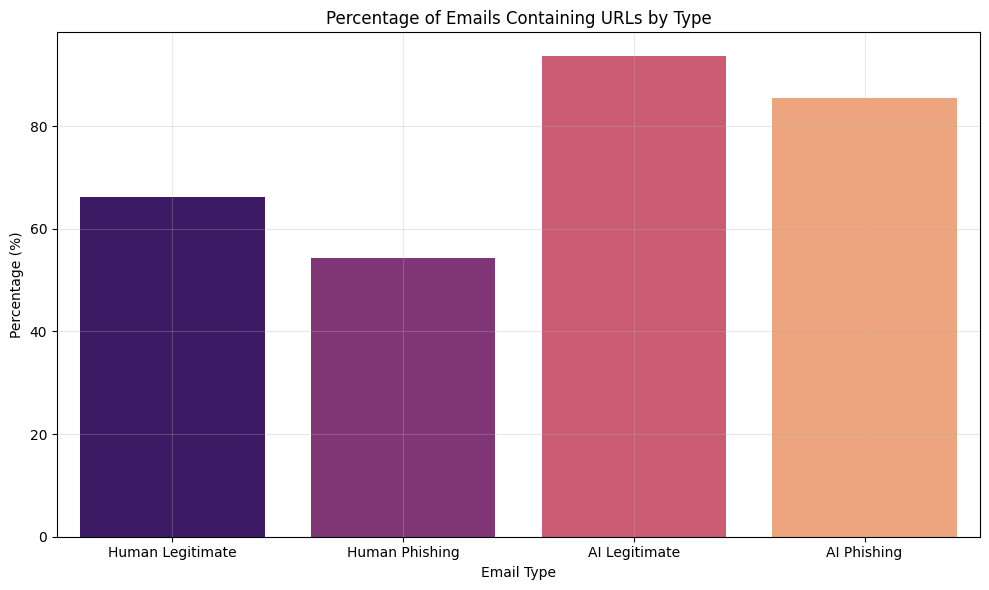

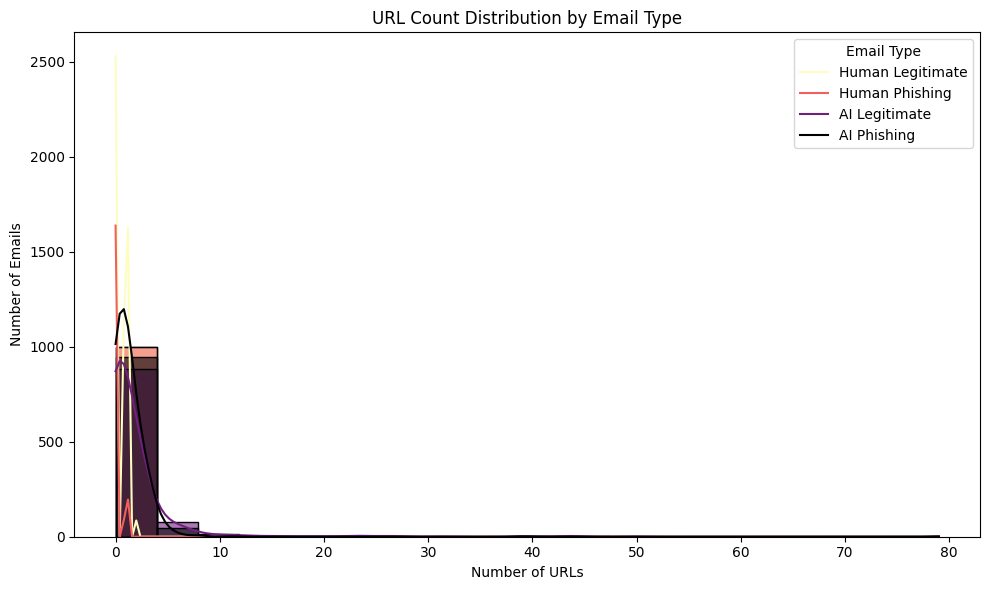


URL Count Stats by Class:
        count      mean       std  min  25%  50%  75%   max
label                                                      
0      1000.0  1.334000  3.027145  0.0  0.0  1.0  2.0  79.0
1      1000.0  1.860000  4.475984  0.0  0.0  1.0  2.0  50.0
2       998.0  0.935872  0.245104  0.0  1.0  1.0  1.0   1.0
3      1000.0  0.859000  0.362285  0.0  1.0  1.0  1.0   2.0

Percentage of Emails with URLs:
  Human Legitimate: 66.2%
  Human Phishing: 54.3%
  AI Legitimate: 93.6%
  AI Phishing: 85.4%


In [ ]:
# ============================================================
#  URL ANALYSIS
# ============================================================

# Extract URLs using regex
def extract_urls(text):
    pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    return re.findall(pattern, str(text))

# Count URLs per email
df['url_count'] = df['text'].apply(lambda x: len(extract_urls(x)))

# Check if email contains any URL
df['has_url'] = df['url_count'].apply(lambda x: 1 if x > 0 else 0)

# Plot 3: URL count boxplot by class
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, x='label', y='url_count',
    palette='coolwarm', hue='label',
    legend=False, showfliers=False
)
plt.xticks([0,1,2,3], list(label_names.values()))
plt.title('URL Count per Email by Type')
plt.xlabel('Email Type')
plt.ylabel('Number of URLs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 4: % of emails containing URLs per class
url_presence = df.groupby('label')['has_url'].mean() * 100

plt.figure(figsize=(10, 6))
sns.barplot(
    x=list(label_names.values()),
    y=url_presence.values,
    palette='magma',
    hue=list(label_names.values()),
    legend=False
)
plt.title('Percentage of Emails Containing URLs by Type')
plt.xlabel('Email Type')
plt.ylabel('Percentage (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 5: URL count distribution
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df, x='url_count',
    hue='label', bins=20,
    palette='magma', alpha=0.6, kde=True
)
plt.legend(labels=list(label_names.values()), title='Email Type')
plt.title('URL Count Distribution by Email Type')
plt.xlabel('Number of URLs')
plt.ylabel('Number of Emails')
plt.tight_layout()
plt.show()
# Print URL stats
print("\nURL Count Stats by Class:")
print(df.groupby('label')['url_count'].describe())

print("\nPercentage of Emails with URLs:")
for label, name in label_names.items():
    pct = df[df['label'] == label]['has_url'].mean() * 100
    print(f"  {name}: {pct:.1f}%")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


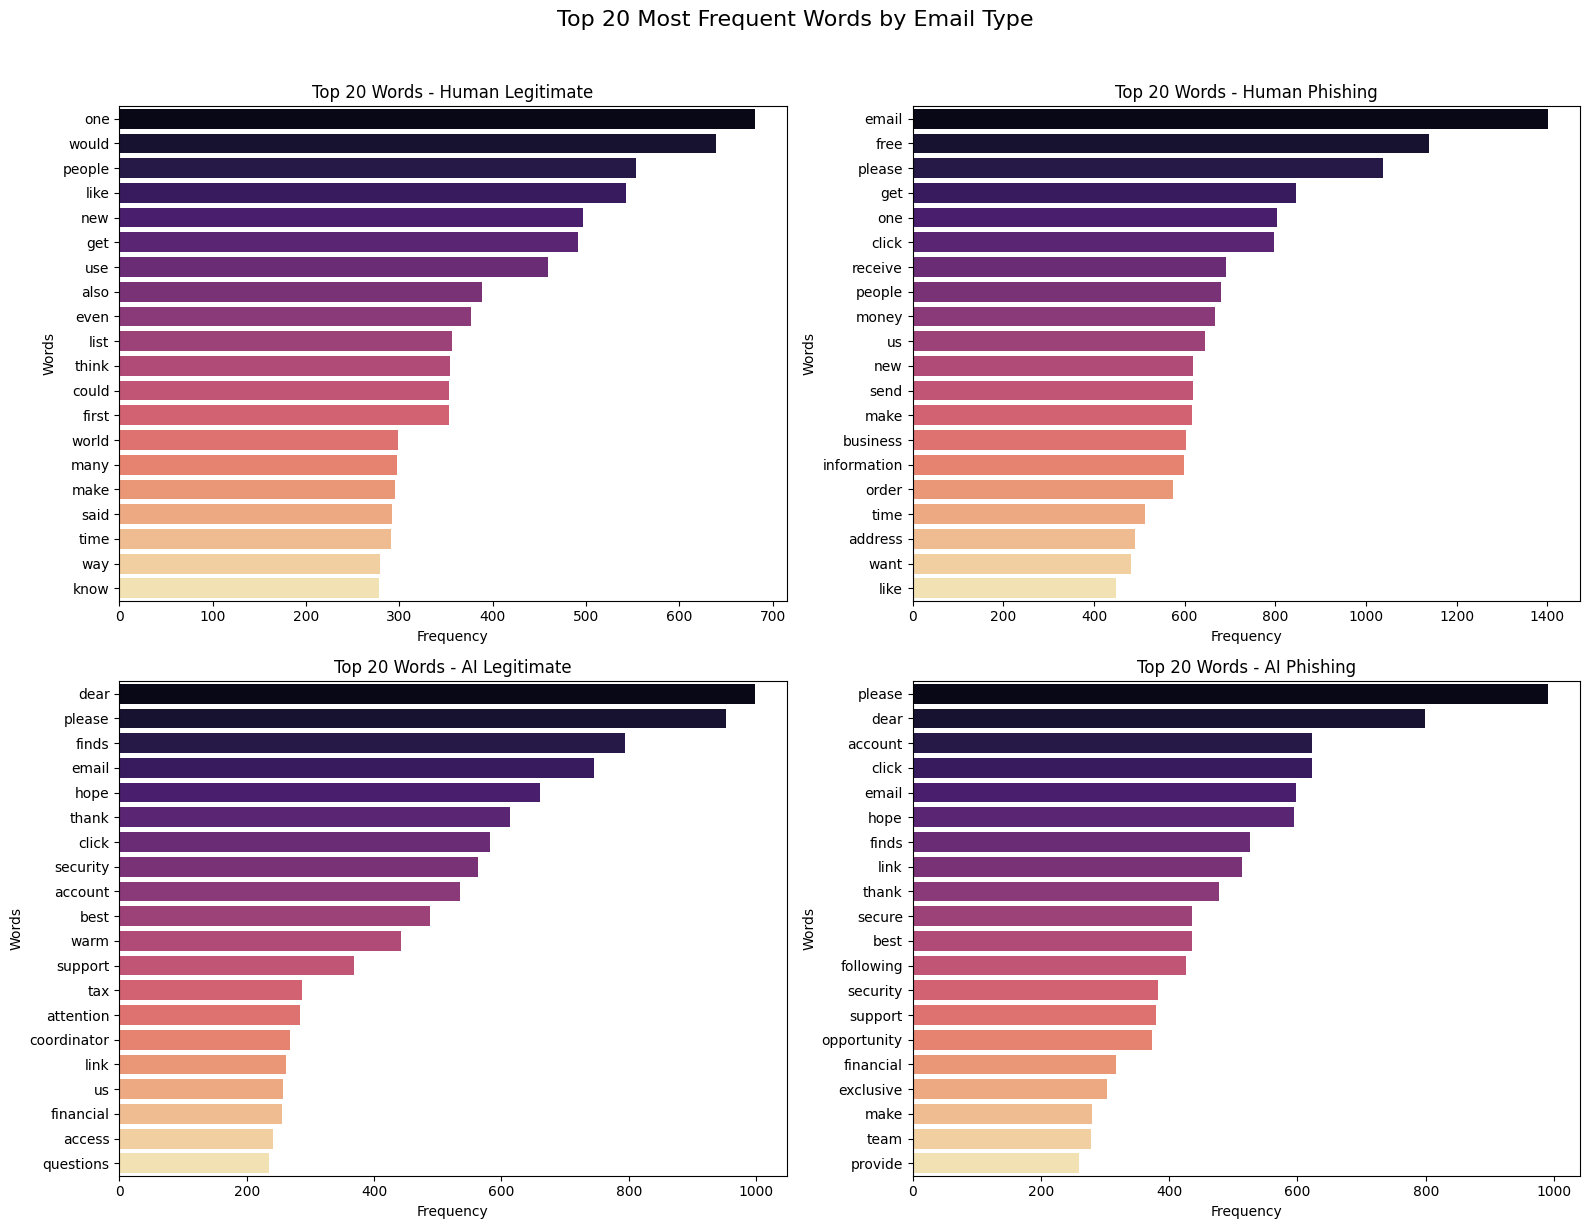

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def get_top_words(df, label, n=20):
    text = ' '.join(df[df['label'] == label]['text']).lower()
    words = text.split()
    filtered = [w for w in words if w.isalpha() and w not in stop_words]
    return Counter(filtered).most_common(n)

# Define all 4 classes
classes = {
    0: 'Human Legitimate',
    1: 'Human Phishing',
    2: 'AI Legitimate',
    3: 'AI Phishing'
}

# Plot top 20 words for each class
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (label, title) in enumerate(classes.items()):
    word_freq = get_top_words(df, label, n=20)
    words, counts = zip(*word_freq)

    sns.barplot(
        x=list(counts),
        y=list(words),
        palette='magma',
        hue =list(words),
        legend= False,
        ax=axes[i]
    )
    axes[i].set_title(f'Top 20 Words - {title}')
    axes[i].set_xlabel('Frequency')
    axes[i].set_ylabel('Words')

plt.suptitle('Top 20 Most Frequent Words by Email Type', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

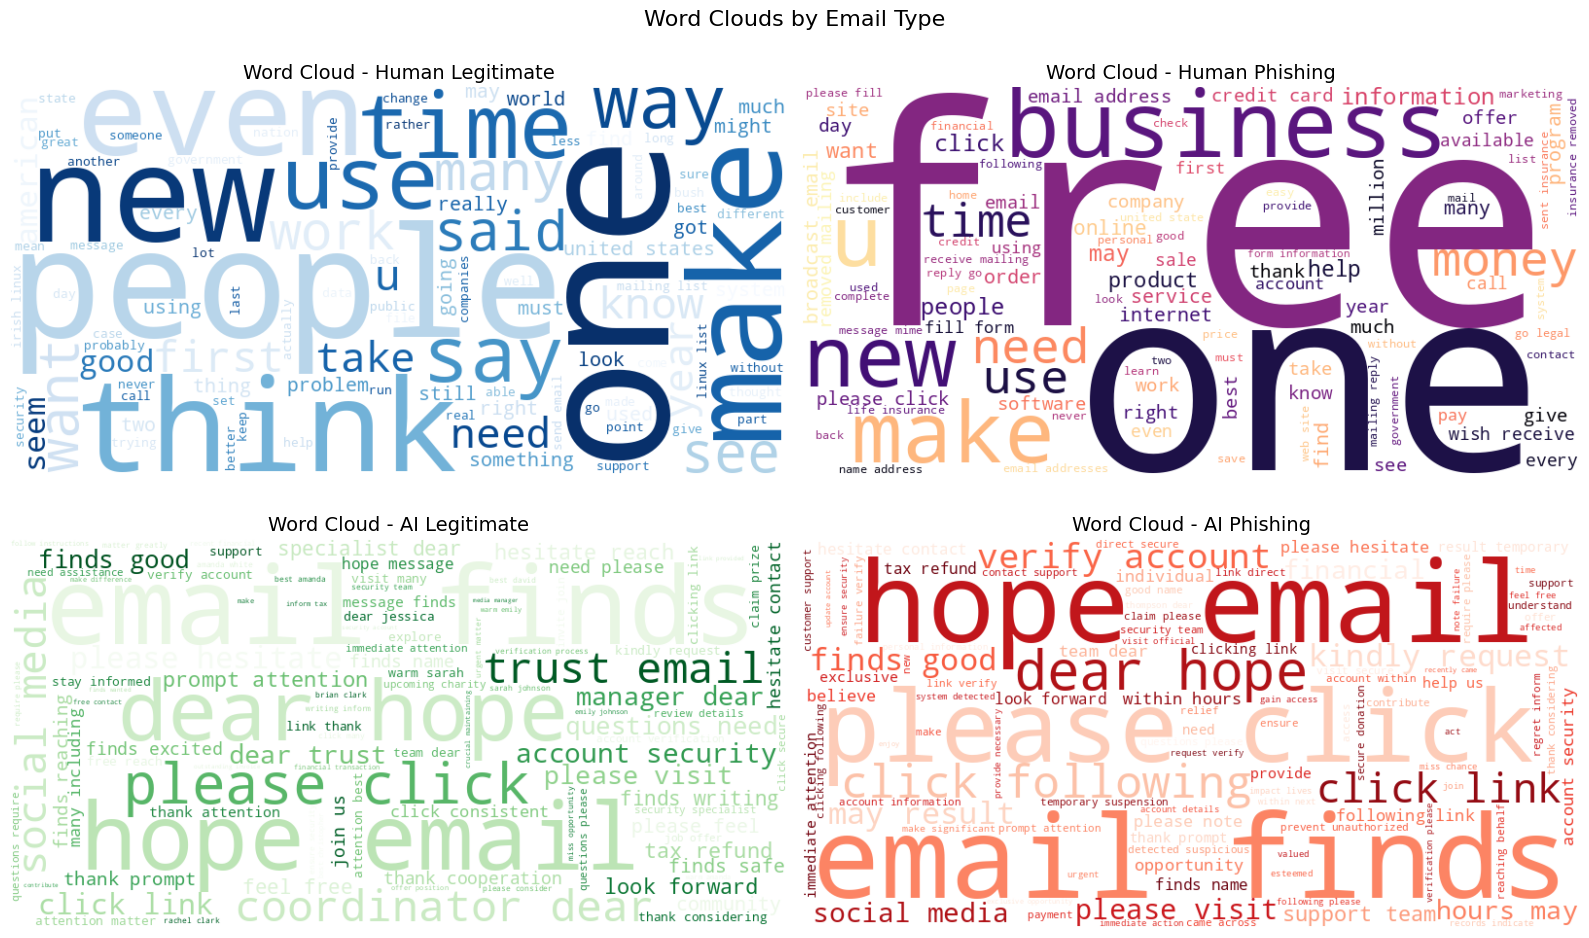

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def get_filtered_words(df, label):
    text = ' '.join(df[df['label'] == label]['text']).lower()
    words = text.split()
    return ' '.join([w for w in words if w.isalpha() and w not in stop_words])

# Define all 4 classes
classes = {
    0: 'Human Legitimate',
    1: 'Human Phishing',
    2: 'AI Legitimate',
    3: 'AI Phishing'
}

colormaps = {
    0: 'Blues',
    1: 'magma',
    2: 'Greens',
    3: 'Reds'
}

# Plot wordcloud for each class
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (label, title) in enumerate(classes.items()):
    text = get_filtered_words(df, label)
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colormaps[label],
        max_words=100
    ).generate(text)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Word Cloud - {title}', fontsize=14)

plt.suptitle('Word Clouds by Email Type', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
!pip install torch
import torch
print(torch.__version__)

2.10.0+cu128


In [ ]:
!pip install scikit-learn

In [ ]:
!pip install transformers

In [ ]:
import re
import torch
import pandas as pd
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

In [ ]:
from sklearn.model_selection import train_test_split

# Split data
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    df['text'].tolist(), df['label'].tolist(),
    test_size=0.2, random_state=42, stratify=df['label']
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,  # 10% of total
    random_state=42, stratify=train_val_labels
)

total = len(df)
print("Train size:", len(train_texts), f"({len(train_texts)/total:.0%})")
print("Val size:  ", len(val_texts),   f"({len(val_texts)/total:.0%})")
print("Test size: ", len(test_texts),  f"({len(test_texts)/total:.0%})")


Train size: 2798 (70%)
Val size:   400 (10%)
Test size:  800 (20%)


In [ ]:
# ── 2. Check label distribution ───────────────────────────────────────────────

print("\nOriginal dataset:")
print(df['label'].value_counts(normalize=True))

train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
print("\nTrain set:")
print(train_df['label'].value_counts(normalize=True))

val_df = pd.DataFrame({'text': val_texts, 'label': val_labels})
print("\nValidation set:")
print(val_df['label'].value_counts(normalize=True))

test_df = pd.DataFrame({'text': test_texts, 'label': test_labels})
print("\nTest set:")
print(test_df['label'].value_counts(normalize=True))


Original dataset:
label
0    0.250125
1    0.250125
3    0.250125
2    0.249625
Name: proportion, dtype: float64

Train set:
label
1    0.250179
3    0.250179
0    0.250179
2    0.249464
Name: proportion, dtype: float64

Validation set:
label
1    0.25
2    0.25
3    0.25
0    0.25
Name: proportion, dtype: float64

Test set:
label
0    0.25
2    0.25
3    0.25
1    0.25
Name: proportion, dtype: float64


In [ ]:
# ── 3. Tokenize ───────────────────────────────────────────────────────────────

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
val_encodings   = tokenizer(val_texts,   truncation=True, padding=True, max_length=512)
test_encodings  = tokenizer(test_texts,  truncation=True, padding=True, max_length=512)

print(" Tokenization done!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

 Tokenization done!


In [ ]:
# ── 4. Dataset class ──────────────────────────────────────────────────────────

class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset   = EmailDataset(val_encodings,   val_labels)
test_dataset  = EmailDataset(test_encodings,  test_labels)

print(" Datasets created!")

 Datasets created!


In [ ]:
# ── 5. Model ──────────────────────────────────────────────────────────────────

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)
print("Fresh BERT model loaded!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh BERT model loaded!


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro'
    )
    acc = accuracy_score(labels, preds)
    return {
        'accuracy' : acc,
        'f1'       : f1,
        'precision': precision,
        'recall'   : recall
    }


In [ ]:
# ── 7. Training arguments ─────────────────────────────────────────────────────

training_args = TrainingArguments(
    output_dir='./results_v2',
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,             # ✅ 5 epochs
    weight_decay=0.01,
    optim="adamw_torch",
    logging_strategy="epoch",
    load_best_model_at_end=True,    # ✅ auto picks best epoch
    metric_for_best_model="f1",
    greater_is_better=True,
    dataloader_pin_memory=False
)


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)




In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.400082,0.078138,0.980000,0.979989,0.980607,0.980000
2,0.025551,0.047597,0.992500,0.992500,0.992573,0.992500
3,0.005066,0.043994,0.992500,0.992500,0.992573,0.992500
4,0.001548,0.051961,0.990000,0.990000,0.990049,0.990000
5,0.001315,0.046942,0.992500,0.992500,0.992573,0.992500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=875, training_loss=0.0867125095810209, metrics={'train_runtime': 1481.5521, 'train_samples_per_second': 9.443, 'train_steps_per_second': 0.591, 'total_flos': 3680989763543040.0, 'train_loss': 0.0867125095810209, 'epoch': 5.0})

In [ ]:
# ── 10. Evaluate on test set ──────────────────────────────────────────────────

results = trainer.evaluate(eval_dataset=test_dataset)
print("\nTest set results:", results)


Test set results: {'eval_loss': 0.04088127240538597, 'eval_accuracy': 0.99125, 'eval_f1': 0.9912374219129914, 'eval_precision': 0.9912433454400716, 'eval_recall': 0.99125, 'eval_runtime': 26.2246, 'eval_samples_per_second': 30.506, 'eval_steps_per_second': 1.907, 'epoch': 5.0}


In [ ]:
# Per-class breakdown (not just weighted average)
from sklearn.metrics import classification_report

preds = trainer.predict(test_dataset)
pred_labels = preds.predictions.argmax(-1)

print(classification_report(
    test_labels,
    pred_labels,
    target_names=["Human Legitimate", "Human Phishing", "AI Legitimate", "AI Phishing"]
))

                  precision    recall  f1-score   support

Human Legitimate       0.99      0.98      0.99       200
  Human Phishing       0.98      0.98      0.98       200
   AI Legitimate       1.00      1.00      1.00       200
     AI Phishing       0.99      1.00      1.00       200

        accuracy                           0.99       800
       macro avg       0.99      0.99      0.99       800
    weighted avg       0.99      0.99      0.99       800



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Extract predicted labels and true labels from the test set
y_pred = trainer.predict(test_dataset).predictions.argmax(axis=1)
y_true = test_labels

# Define target names for plotting
target_names = ["Human Legitimate", "Human Phishing", "AI Legitimate", "AI Phishing"]

# Calculate per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

# Create a DataFrame for easy plotting
metrics_data = []
for i, class_name in enumerate(target_names):
    metrics_data.append({'Class': class_name, 'Metric': 'Precision', 'Score': precision[i]})
    metrics_data.append({'Class': class_name, 'Metric': 'Recall', 'Score': recall[i]})
    metrics_data.append({'Class': class_name, 'Metric': 'F1-Score', 'Score': f1[i]})

metrics_df = pd.DataFrame(metrics_data)

# Plotting grouped bar chart for precision, recall, and F1-score
plt.figure(figsize=(14, 8))
sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_df, palette='viridis')
plt.ylim(0.0, 1.05) # Set y-axis limit for scores
plt.title('Per-Class Precision, Recall, and F1-Score')
plt.ylabel('Score')
plt.xlabel('Email Type')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting overall accuracy
overall_accuracy = accuracy_score(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.barplot(x=['Overall Accuracy'], y=[overall_accuracy], palette='magma')
plt.ylim(0.0, 1.05)
plt.title('Overall Model Accuracy')
plt.ylabel('Accuracy Score')
plt.text(0, overall_accuracy + 0.02, f'{overall_accuracy:.4f}', ha='center', va='bottom', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

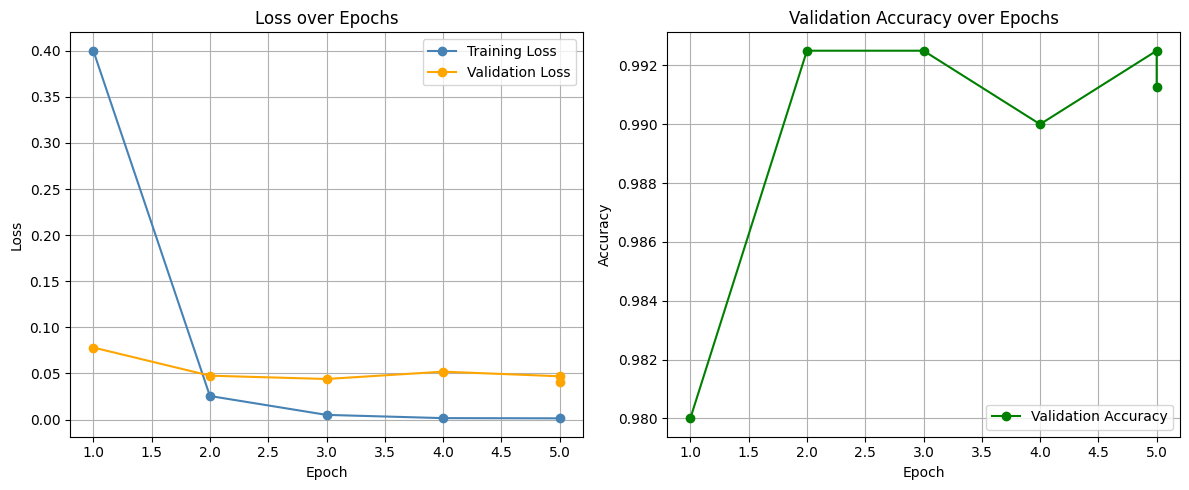

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_entries = [e for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_entries  = [e for e in log_history if 'eval_loss' in e]

train_loss   = [e['loss'] for e in train_entries]
train_epochs = [e['epoch'] for e in train_entries]

eval_loss    = [e['eval_loss'] for e in eval_entries]
eval_acc     = [e['eval_accuracy'] for e in eval_entries]
eval_epochs  = [e['epoch'] for e in eval_entries]

plt.figure(figsize=(12, 5))

# -- Loss plot --
plt.subplot(1, 2, 1)
plt.plot(train_epochs, train_loss, marker='o', label='Training Loss', color='steelblue')
plt.plot(eval_epochs,  eval_loss,  marker='o', label='Validation Loss', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.grid(True)

# -- Accuracy plot --
plt.subplot(1, 2, 2)
plt.plot(eval_epochs, eval_acc, marker='o', color='green', label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
#  SAVE THE FINAL MODEL & TOKENIZER
# ============================================================

from google.colab import drive
drive.mount('/content/drive')
import os

save_path = "/content/drive/MyDrive/phishing_model/new_model"

os.makedirs(save_path, exist_ok=True)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Model and tokenizer saved to Google Drive successfully!")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to Google Drive successfully!


In [ ]:
# ============================================================
#  TOKENIZE TEST DATA
# ============================================================

test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=512)


In [ ]:
# ============================================================
#  CONVERT TO PYTORCH DATASET
# ============================================================
test_dataset = EmailDataset(test_encodings, test_labels)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Run predictions on the test set
test_results = trainer.predict(test_dataset)

# Extract predicted class labels
y_pred = test_results.predictions.argmax(axis=1)
y_true = test_labels

# Print all core metrics
print("Final Test Evaluation Metrics:\n")
print("Accuracy       :", accuracy_score(y_true, y_pred))
print("Precision      :", precision_score(y_true, y_pred, average='macro'))
print("Recall         :", recall_score(y_true, y_pred, average='macro'))
print("F1 Score       :", f1_score(y_true, y_pred, average='macro'))

print("\nClassification Report:\n")
print(classification_report(
    y_true, y_pred,
    target_names=["Human Legitimate", "Human Phishing", "AI Legitimate", "AI Phishing"]
))



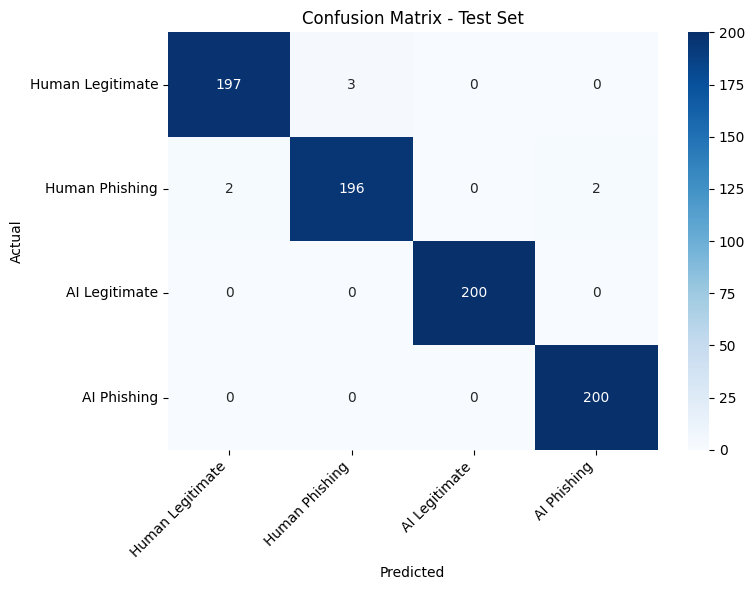

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Human Legitimate', 'Human Phishing', 'AI Legitimate', 'AI Phishing'],
    yticklabels=['Human Legitimate', 'Human Phishing', 'AI Legitimate', 'AI Phishing']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ── INFERENCE: Predict on new email ──────────────────────────────────────────
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Load saved model
load_path = "/content/drive/MyDrive/phishing_model/new_model"
tokenizer = BertTokenizer.from_pretrained(load_path)
model = BertForSequenceClassification.from_pretrained(load_path)
model.eval()

label_map = {
    0: "Human Legitimate",
    1: "Human Phishing",
    2: "AI Legitimate",
    3: "AI Phishing"
}

def predict_email(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )
    with torch.no_grad():
        outputs = model(**inputs)
    pred = outputs.logits.argmax(-1).item()
    return label_map[pred]

# Test it
email = "Congratulations! You have won a $1000 gift card. Click here to claim."
print("Prediction:", predict_email(email))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Prediction: AI Phishing
